Faber-Jackson Relation plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Firstly, we define the different columns from the data file. We are given the Mass and velocity dispersion. Mass and luminosity are proportional so for the plot we have to log the Mass to depict a representation of Absolute Magnitude. 

In [2]:
skiprow, catid, type, sigma_re, mstar = np.loadtxt('cleaned_data.txt', unpack=True) # Data saved as array in text file
yvalues = sigma_re
xvalues = -2.5 * np.log10(mstar) + 5 * np.log10(70) + 25 # Convert star mass to absolute magnitude. star mass is proportional to luminosity, and absolute magnitude is proportional to luminosity. The constant term is the distance modulus for 70 Mpc.

Now we add a linear fit.

In [3]:
M = xvalues
sigma = yvalues

a,b= np.polyfit(M, sigma, 1) # Fit a linear regression to the data
xcoords = np.linspace(np.min(M), np.max(M), 100) # Create an array of x values for the linear regression line
ycoords = a * xcoords + b # Calculate the y values of the linear regression line

Now we have to plot our data in a graph.

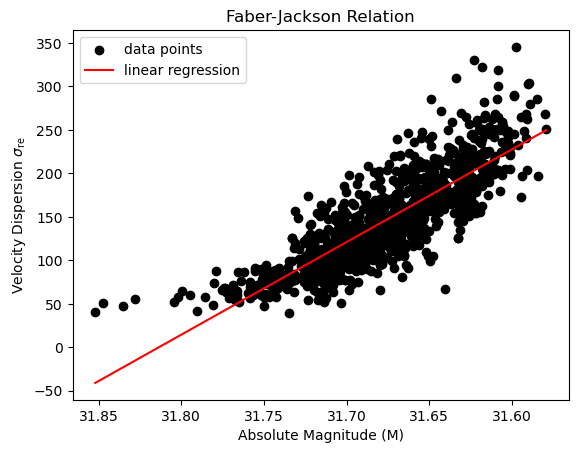

In [4]:
plt.scatter(xvalues, yvalues, color="black", label="data points") #show data points as black dots
plt.plot(xcoords, ycoords, color="red", label="linear regression") #show linear regression as red line
plt.gca().invert_xaxis() #invert x axis to match the convention of absolute magnitude (brighter objects have lower magnitudes)

plt.legend(loc="best")
plt.title("Faber-Jackson Relation")
plt.xlabel("Absolute Magnitude (M)")
plt.ylabel("Velocity Dispersion $\\sigma_{\\text{re}}$")
plt.show()

In [9]:
from scipy.optimize import curve_fit

def relation(Mag, k, g):
    return k * Mag **g

params, covariance = curve_fit(relation, M, sigma, p0=[1, 2])

k, g = params 

print("k =", k)
print("g =", g)

k = 117.34510177709002
g = -31.916006424038116


/var/folders/c8/yj9328h51v56wpnw1m_8ynxc0000gn/T/ipykernel_1707/2150236812.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(relation, M, sigma, p0=[1, 2])
